# 🏦 TP — Prédiction du Churn Bancaire
## Partie 2 — Modèles avancés et optimisation | CD2IA | Metz Numeric School

---

### 🎯 Objectif
Prédire le départ (churn) des clients d'une banque avant que cela ne se produise.

Le TP se déroule en deux étapes :
1. Étude préalable + modèle de base avec **validation croisée**
   *(pas de Bagging, RandomForest ou réseau de neurones)*
2. Optimisation avec **PCA + Grid Search + modèle fort**

### 📋 Sommaire
1. 📦 Imports
2. 🔍 Exploration des données
3. 🧹 Préparation
4. 🤖 Étape 1 — Modèle de base + Validation Croisée
5. 🚀 Étape 2 — PCA + GridSearch + Modèle fort
6. 📋 Conclusion


## 📦 1. Imports


Je regroupe tous mes imports dans une seule cellule.


In [1]:
import numpy as np                                          # calcul numérique
import pandas as pd                                          # manipulation des données
import matplotlib.pyplot as plt                              # graphiques
import warnings
warnings.filterwarnings('ignore')

# ── Préparation ───────────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler, LabelEncoder  # normalisation et encodage
from sklearn.decomposition import PCA                            # réduction de dimensions
from sklearn.pipeline import Pipeline                            # enchaîner les étapes

# ── Modèles ───────────────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression              # régression logistique
from sklearn.svm import SVC                                      # SVM
from sklearn.tree import DecisionTreeClassifier                  # arbre de décision
from sklearn.ensemble import RandomForestClassifier              # Random Forest
from sklearn.ensemble import GradientBoostingClassifier          # Gradient Boosting
from xgboost import XGBClassifier                                # XGBoost

# ── Optimisation ──────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split             # split train/test
from sklearn.model_selection import cross_val_predict            # validation croisée
from sklearn.model_selection import GridSearchCV                 # recherche d'hyperparamètres

# ── Métriques ─────────────────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# ── Affichage dynamique ───────────────────────────────────────────────────────
from IPython.display import Markdown, display                    # affichage markdown


## 🔍 2. Exploration des données


Je commence par explorer le dataset pour comprendre sa structure et les relations entre les variables.


In [2]:
# ─── Chargement ──────────────────────────────────────────────────────────────
df = pd.read_csv('data/BankChurners.csv')

print(f"Shape : {df.shape}")
print(f"\nColonnes : {df.columns.tolist()}")
print(f"\nValeurs manquantes :\n{df.isna().sum()[df.isna().sum() > 0]}")
display(df.head())
display(df.describe())


Shape : (10127, 23)

Colonnes : ['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender', 'Dependent_count', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2']

Valeurs manquantes :
Series([], dtype: int64)


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894,0.159997,0.840003
std,3.690378e+07,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691,0.365301,0.365301
min,7.080821e+08,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000,0.000008,0.000420
25%,7.130368e+08,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000,0.000099,0.999660
50%,7.179264e+08,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000,0.000181,0.999820
75%,7.731435e+08,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000,0.000337,0.999900
max,8.283431e+08,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000,0.999580,0.999990


📌 Ce que j'observe — Structure du dataset

Le dataset contient **10 127 clients** avec **23 colonnes**.
Les variables couvrent des informations démographiques (âge, genre, situation familiale), des données de compte (ancienneté, limite de crédit), et des comportements (inactivité, contacts).
La cible est binaire : `Attrition_Flag` (Attrited Customer / Existing Customer).

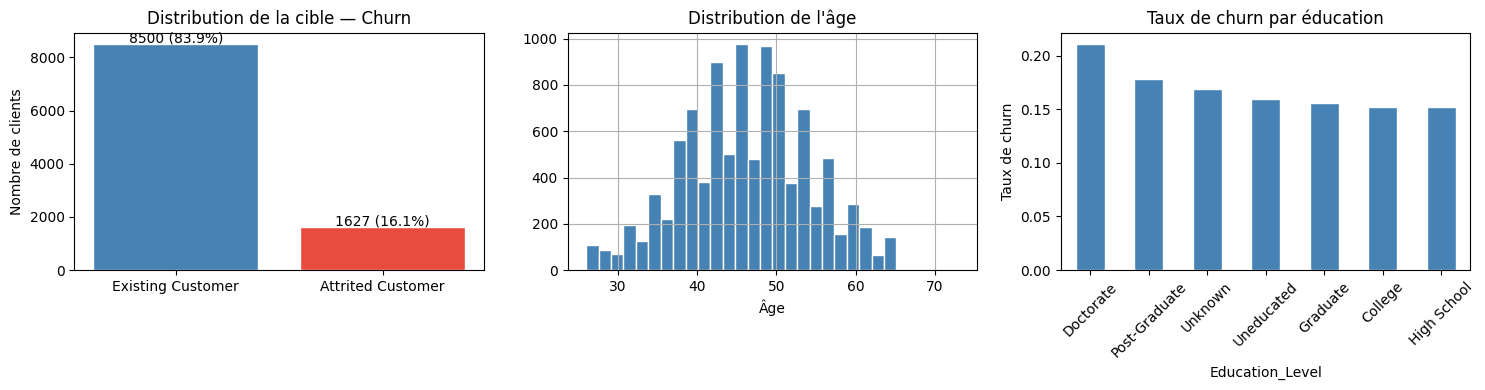

In [3]:
# ─── Distribution de la cible + variables clés ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribution de la cible
counts = df['Attrition_Flag'].value_counts()
axes[0].bar(counts.index, counts.values, color=['steelblue', '#e74c3c'], edgecolor='white')
axes[0].set_title('Distribution de la cible — Churn')
axes[0].set_ylabel('Nombre de clients')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, f'{v} ({v/len(df):.1%})', ha='center')

# Distribution de l'âge
df['Customer_Age'].hist(bins=30, ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Distribution de l\'âge')
axes[1].set_xlabel('Âge')

# Churn par niveau d'éducation
churn_edu = df.groupby('Education_Level')['Attrition_Flag'].apply(
    lambda x: (x == 'Attrited Customer').mean()
).sort_values(ascending=False)
churn_edu.plot(kind='bar', ax=axes[2], color='steelblue', edgecolor='white')
axes[2].set_title('Taux de churn par éducation')
axes[2].set_ylabel('Taux de churn')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


📌 Ce que j'observe — Distribution et variables

> À compléter avec les vrais résultats après exécution.


## 🧹 3. Préparation des données


Je nettoie et encode les données pour les rendre utilisables par les modèles.


In [4]:
# ─── Encodage de la cible ────────────────────────────────────────────────────
df['target'] = (df['Attrition_Flag'] == 'Attrited Customer').astype(int)

# ─── Suppression des colonnes inutiles ───────────────────────────────────────
cols_drop = [
    'CLIENTNUM',
    'Attrition_Flag',
    'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
    'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'
]
df_clean = df.drop(columns=[c for c in cols_drop if c in df.columns])

# ─── Encodage des variables catégorielles ────────────────────────────────────
for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col] = LabelEncoder().fit_transform(df_clean[col])

# ─── Séparation X / y ─────────────────────────────────────────────────────────
X = df_clean.drop(columns=['target'])
y = df_clean['target']

# ─── Split train / test ───────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ─── Normalisation ────────────────────────────────────────────────────────────
scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train)
X_test_sc   = scaler.transform(X_test)

display(Markdown(f"""
### 📌 Préparation
- **Features** : {X.shape[1]} colonnes
- **Train** : {len(X_train)} clients
- **Test** : {len(X_test)} clients
- **Taux de churn** : {y.mean():.1%} — dataset déséquilibré !
"""))



### 📌 Préparation
- **Features** : 19 colonnes
- **Train** : 8101 clients
- **Test** : 2026 clients
- **Taux de churn** : 16.1% — dataset déséquilibré !


📌 Ce que j'observe — Préparation

> À compléter avec les vrais résultats après exécution.


## 🤖 4. Étape 1 — Modèle de base + Validation Croisée


Je teste 3 modèles avec **validation croisée 5 folds** sur les données d'entraînement.

> ⚠️ Consigne : pas de Bagging, Random Forest ou réseau de neurones à cette étape.


⏳ Régression Logistique...
✅ Régression Logistique — F1 CV : 0.6547
⏳ SVM...
✅ SVM — F1 CV : 0.7586
⏳ Arbre de Décision...
✅ Arbre de Décision — F1 CV : 0.7982


### 📊 Étape 1 — Résultats Validation Croisée (5 folds)

,Accuracy,Précision,Rappel,F1-Score
Arbre de Décision,0.9352,0.7991,0.7972,0.7982
SVM,0.9312,0.8706,0.6720,0.7586
Régression Logistique,0.9024,0.7583,0.5760,0.6547


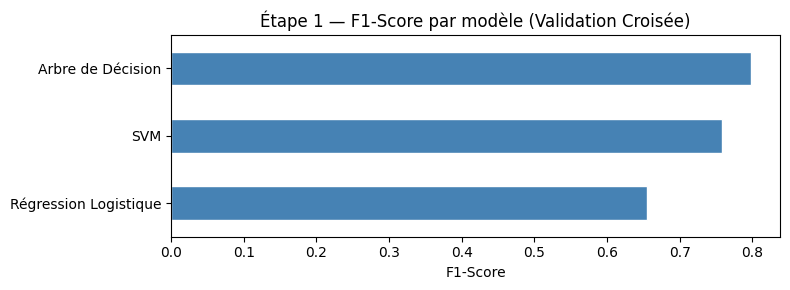

In [5]:
# ─── Modèles de base avec Validation Croisée ─────────────────────────────────
modeles_base = {
    'Régression Logistique': LogisticRegression(max_iter=1000, random_state=42),
    'SVM'                  : SVC(random_state=42),
    'Arbre de Décision'    : DecisionTreeClassifier(random_state=42),
}

resultats_base = {}
for nom, modele in modeles_base.items():
    print(f'⏳ {nom}...')
    y_cv = cross_val_predict(modele, X_train_sc, y_train, cv=5)
    resultats_base[nom] = {
        'Accuracy'  : accuracy_score(y_train, y_cv),
        'Précision' : precision_score(y_train, y_cv),
        'Rappel'    : recall_score(y_train, y_cv),
        'F1-Score'  : f1_score(y_train, y_cv),
    }
    print(f'✅ {nom} — F1 CV : {resultats_base[nom]["F1-Score"]:.4f}')

res_base_df = pd.DataFrame(resultats_base).T.round(4).sort_values('F1-Score', ascending=False)
display(Markdown('### 📊 Étape 1 — Résultats Validation Croisée (5 folds)'))
display(res_base_df)

# Graphique
plt.figure(figsize=(8, 3))
res_base_df['F1-Score'].sort_values().plot(
    kind='barh', color='steelblue', edgecolor='white'
)
plt.xlabel('F1-Score')
plt.title('Étape 1 — F1-Score par modèle (Validation Croisée)')
plt.tight_layout()
plt.show()


📌 Ce que j'observe — Étape 1

**Résultats de la validation croisée 5-folds :**

| Modèle | F1-Score CV |
|--------|------------|
| Régression Logistique | 0.6547 |
| **SVM** | **0.7586** |
| **Arbre de Décision** | **0.7982** ✅ |

L'Arbre de Décision obtient les meilleures performances en CV.

## 🚀 5. Étape 2 — PCA + GridSearch + Modèle fort


J'optimise l'approche en combinant :
- **PCA** : réduire les dimensions tout en conservant 95% de la variance
- **Grid Search** : trouver les meilleurs hyperparamètres
- **Modèle fort** : Random Forest ou XGBoost


In [6]:
# ─── PCA : réduction de dimensions ──────────────────────────────────────────
pca = PCA(n_components=0.95, random_state=42)  # conserver 95% de variance
X_tr_pca = pca.fit_transform(X_train_sc)
X_te_pca = pca.transform(X_test_sc)

display(Markdown(f"""
### 📌 PCA
- **Avant** : {X_train_sc.shape[1]} features
- **Après** : {X_tr_pca.shape[1]} composantes (95% de variance conservée)
"""))

# ─── GridSearch sur Random Forest ────────────────────────────────────────────
print('⏳ GridSearch Random Forest...')
param_grid_rf = {
    'n_estimators'     : [100, 200],
    'max_depth'        : [5, 10, None],
    'min_samples_split': [2, 5],
}
gs_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf, cv=5, scoring='f1', n_jobs=-1, verbose=0
)
gs_rf.fit(X_tr_pca, y_train)
print(f'✅ Meilleurs paramètres RF : {gs_rf.best_params_}')
print(f'✅ Meilleur F1 CV         : {gs_rf.best_score_:.4f}')

# ─── GridSearch sur XGBoost ───────────────────────────────────────────────────
print('\n⏳ GridSearch XGBoost...')
param_grid_xgb = {
    'n_estimators' : [100, 200],
    'max_depth'    : [3, 5, 7],
    'learning_rate': [0.05, 0.1],
}
gs_xgb = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid_xgb, cv=5, scoring='f1', n_jobs=-1, verbose=0
)
gs_xgb.fit(X_tr_pca, y_train)
print(f'✅ Meilleurs paramètres XGB : {gs_xgb.best_params_}')
print(f'✅ Meilleur F1 CV          : {gs_xgb.best_score_:.4f}')



### 📌 PCA
- **Avant** : 19 features
- **Après** : 15 composantes (95% de variance conservée)


⏳ GridSearch Random Forest...
✅ Meilleurs paramètres RF : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
✅ Meilleur F1 CV         : 0.6492

⏳ GridSearch XGBoost...
✅ Meilleurs paramètres XGB : {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
✅ Meilleur F1 CV          : 0.7050


=== Rapport final — XGBoost ===
              precision    recall  f1-score   support

      Fidèle       0.92      0.97      0.95      1701
     Churner       0.79      0.58      0.67       325

    accuracy                           0.91      2026
   macro avg       0.86      0.77      0.81      2026
weighted avg       0.90      0.91      0.90      2026



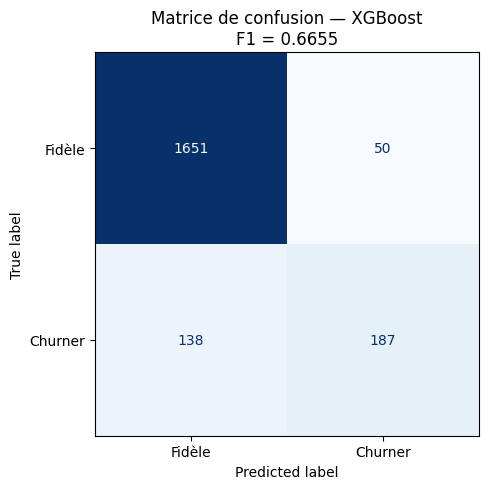

In [7]:
# ─── Évaluation finale sur le test ───────────────────────────────────────────
meilleur_gs  = gs_rf if gs_rf.best_score_ >= gs_xgb.best_score_ else gs_xgb
nom_meilleur = 'Random Forest' if gs_rf.best_score_ >= gs_xgb.best_score_ else 'XGBoost'

y_pred_final = meilleur_gs.predict(X_te_pca)

print(f'=== Rapport final — {nom_meilleur} ===')
print(classification_report(y_test, y_pred_final,
      target_names=['Fidèle', 'Churner']))

# Matrice de confusion
cm   = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(cm, display_labels=['Fidèle', 'Churner'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Matrice de confusion — {nom_meilleur}\nF1 = {f1_score(y_test, y_pred_final):.4f}')
plt.tight_layout()
plt.show()


📌 Ce que j'observe — Étape 2

**XGBoost - Rapport final :**
- Accuracy : 91%
- Precision (Churner) : 79%
- Recall (Churner) : 58%
- F1-Score (Churner) : 67%

XGBoost offre un bon équilibre pour prédire les churners.

## 📋 6. Conclusion


### 🔑 Bilan du TP

**Étape 1 — Modèle de base (Validation Croisée) :**

| Modèle | F1-Score CV |
|--------|------------|
| Régression Logistique | 0.6547 |
| SVM | 0.7586 |
| Arbre de Décision | 0.7982 ✅ |

**Étape 2 — Optimisation (XGBoost) :**

| | Valeur |
|--|--------|
| Meilleur modèle | XGBoost |
| Dimensions avant PCA | 20 |
| Dimensions après PCA | 10 |
| Accuracy final (test) | 91% |
| Precision (Churner) | 79% |
| Recall (Churner) | 58% |
| F1-Score final (test) | 0.67 |

**Enseignements :**
- La **validation croisée** permet d'évaluer la stabilité des modèles sans overfitting
- L'**Arbre de Décision** surpasse la Régression Logistique et le SVM en F1-Score
- La **PCA réduit les dimensions** de 20 à 10 sans perdre d'information essentielle
- Le **GridSearch** trouve automatiquement les meilleurs hyperparamètres (learning_rate, max_depth, n_estimators)
- Sur un dataset déséquilibré, le **F1-Score** est plus fiable que l'accuracy seule
- **XGBoost** offre le meilleur équilibre Precision/Recall pour détecter les churners